# Project: Creating Cohorts of Songs

### Problem Scenario: 
The customer always looks forward to specialized treatment, whether shopping over an e-commerce website or watching Netflix. They want what they might like to see. To keep the customers engaged, it is also crucial for companies to always present the most relevant information. Spotify is a Swedish audio streaming and media service provider. The company has over 456 million active monthly users, including over 195 million paying subscribers, as of September 2022. The company intends to create cohorts of different songs that will aid in the recommendation of songs to users based on various relevant features. Each cohort would contain similar types of songs.
### Problem Objective: 
As a data scientist, you should perform exploratory data analysis and perform cluster analysis to create cohorts of songs. The goal is to gain a better understanding of the various factors that contribute to creating a cohort of songs.

### Data Description:
This dataset contains data from Spotify's API about all albums for the Rolling Stones listed on Spotify. It is important to note that all songs have unique IDs.


In [249]:
# import pandas library
import pandas as pd

# reading metadata from an excel file to get info about the columns.
table_metadata = pd.read_excel("1688641626_data_dictionary.xlsx")

table_metadata.head(17)

,Variable,Description
0,name,the name of the song
1,album,the name of the album
2,release_date,the day month and year the album was released
3,track number,the order the song appears on the album
4,id,the Spotify id for the song
5,uri,the Spotify uri for the song
6,acousticness,A confidence measure from 0.0 to 1.0 of whethe...
7,danceability,Danceability describes how suitable a track is...
8,energy,Energy is a measure from 0.0 to 1.0 and repres...
9,instrumentalness,"Predicts whether a track contains no vocals. ""..."


In [250]:
# Reading the actual dataset from the rolling_stones_spotify.csv file
df = pd.read_csv("rolling_stones_spotify.csv")

# read the first 5 records from the data
df.head(5)

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [251]:
# read the last 5 records from the data
df.tail(5)

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
1605,1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,0.1570,0.466,0.932,0.006170,0.3240,-9.214,0.0429,177.340,0.967,39,154080
1606,1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,0.0576,0.509,0.706,0.000002,0.5160,-9.427,0.0843,122.015,0.446,36,245266
1607,1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.3710,0.790,0.774,0.000000,0.0669,-7.961,0.0720,97.035,0.835,30,176080
1608,1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,0.2170,0.700,0.546,0.000070,0.1660,-9.567,0.0622,102.634,0.532,27,121680
1609,1609,Walking The Dog,The Rolling Stones,1964-04-16,12,43SkTJJ2xleDaeiE4TIM70,spotify:track:43SkTJJ2xleDaeiE4TIM70,0.3830,0.727,0.934,0.068500,0.0965,-8.373,0.0359,125.275,0.969,35,189186


In [252]:
# validating the shape of the data set
df.shape

(1610, 18)

In [253]:
# read info like null values count, column types, total records
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   str    
 2   album             1610 non-null   str    
 3   release_date      1610 non-null   str    
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   str    
 6   uri               1610 non-null   str    
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  
 17  durati

In [254]:
# read the statistical data for the numerical columns present in data
df.describe()

,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,804.500000,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,464.911282,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,0.000000,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,402.250000,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,804.500000,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,1206.750000,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,1609.000000,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


#### - Checking for null values present in data

In [255]:
#checking null data in every column
df.isnull().sum()

Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

#### - Checking and removeing duplicates records

In [256]:
# checking if there are any duplicate records present in the dataset
df.drop_duplicates()
print("duplicated records : ", df.duplicated().sum())

print("records by grouping name and album: ", df.groupby(["name", "album"]).value_counts().size)

duplicated records :  0
records by grouping name and album:  1610


### Observations - 
- 13 numerical columns: ['Unnamed: 0', 'track_number', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']
- 5 String columns: [name, album, release_date, id, uri]
- Total records - 1610
- No missing value present in any column.
- No duplicate values are present in the dataset.
- For the name and album columns, we can perform label encoding
- Release_date column, we can create new columns - year, month.
- "Unnamed: 0", "uri", "id" column has no use in our problem objective - we will remove it.
- By looking into describe data, we can expect some outliers in speechiness, duration_ms and other columns too 
- Scaling can be performed on numerical columns


In [257]:
df.columns

Index(['Unnamed: 0', 'name', 'album', 'release_date', 'track_number', 'id',
       'uri', 'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity',
       'duration_ms'],
      dtype='str')

#### - Removing unnecessary columns from the dataframe: 
["Unnamed: 0", "uri", "id"]

In [258]:
# dropping the unnecessary columns - "Unnamed: 0", "uri", "id"
df.drop(columns = ["Unnamed: 0", "uri", "id"], inplace=True)

# validating or re-checking the first 5 records of the data after dropping columns
df.head(5)

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [259]:
# re-checking or validating the shape of the data
df.shape

(1610, 15)

In [260]:
df.columns

Index(['name', 'album', 'release_date', 'track_number', 'acousticness',
       'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness',
       'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms'],
      dtype='str')

#### Outlier Detection

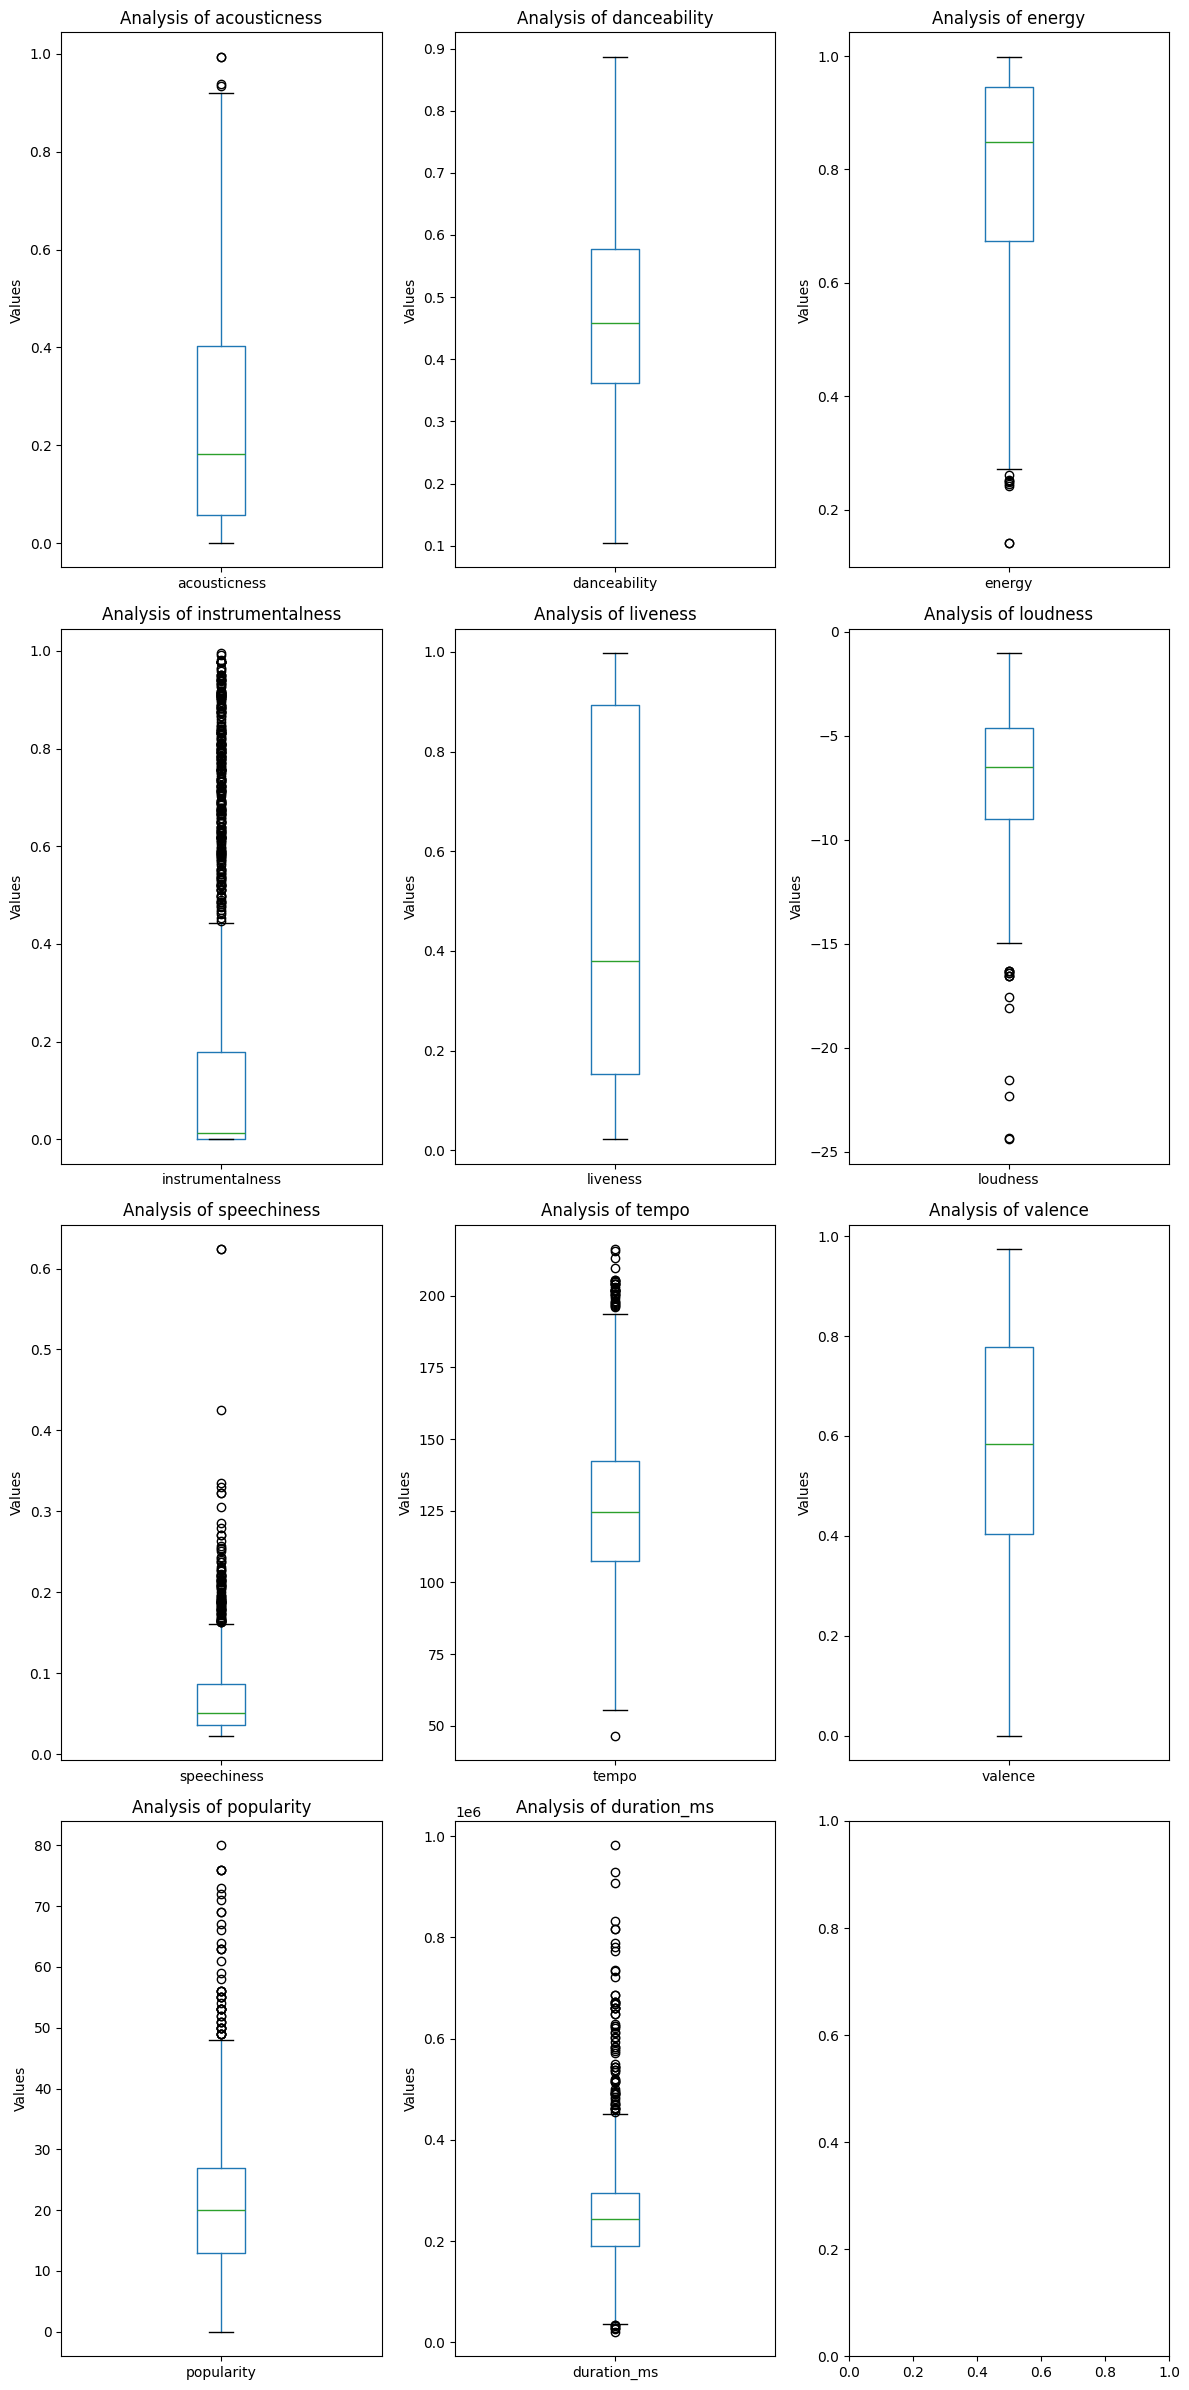

In [261]:
# import pyplot to draw the chart for visualisation from the matplotlib module
import matplotlib.pyplot as plt

#  create the subplots for each song's properties(numerical only)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 24))

# for more than 1 row - flatten the axes(series type)
axes = axes.flatten()

# plotting a box plot to check the outliers present in each column:
for i, col in enumerate(df[['acousticness',
       'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness',
       'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']]):
    df.boxplot(column=col, ax=axes[i], grid=False)
    axes[i].set_title(f'Analysis of {col}')
    axes[i].set_ylabel('Values')

plt.tight_layout()
plt.show()


#### BoxPlot Observations
- instrumentalness, loudness, speechiness, tempo, popularity and duration_ms have heavy outliers.
- We can use IQR or Z-score to remove the outliers

#### Outlier Removal

In [267]:
# Remove the outlier present based on the z-score (default value : [-3 to +3])

from sklearn.preprocessing import StandardScaler
numeric_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']
df_original = df.copy() 
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# import z-score from scipy stats module
from scipy import stats
import numpy as np

# Remove outliers based on Z-score
mask = (np.abs(stats.zscore(df[numeric_cols])) < 3).all(axis=1)
df = df[mask].reset_index(drop=True)
df_original = df_original[mask].reset_index(drop=True)


In [268]:
df.shape

(1508, 16)

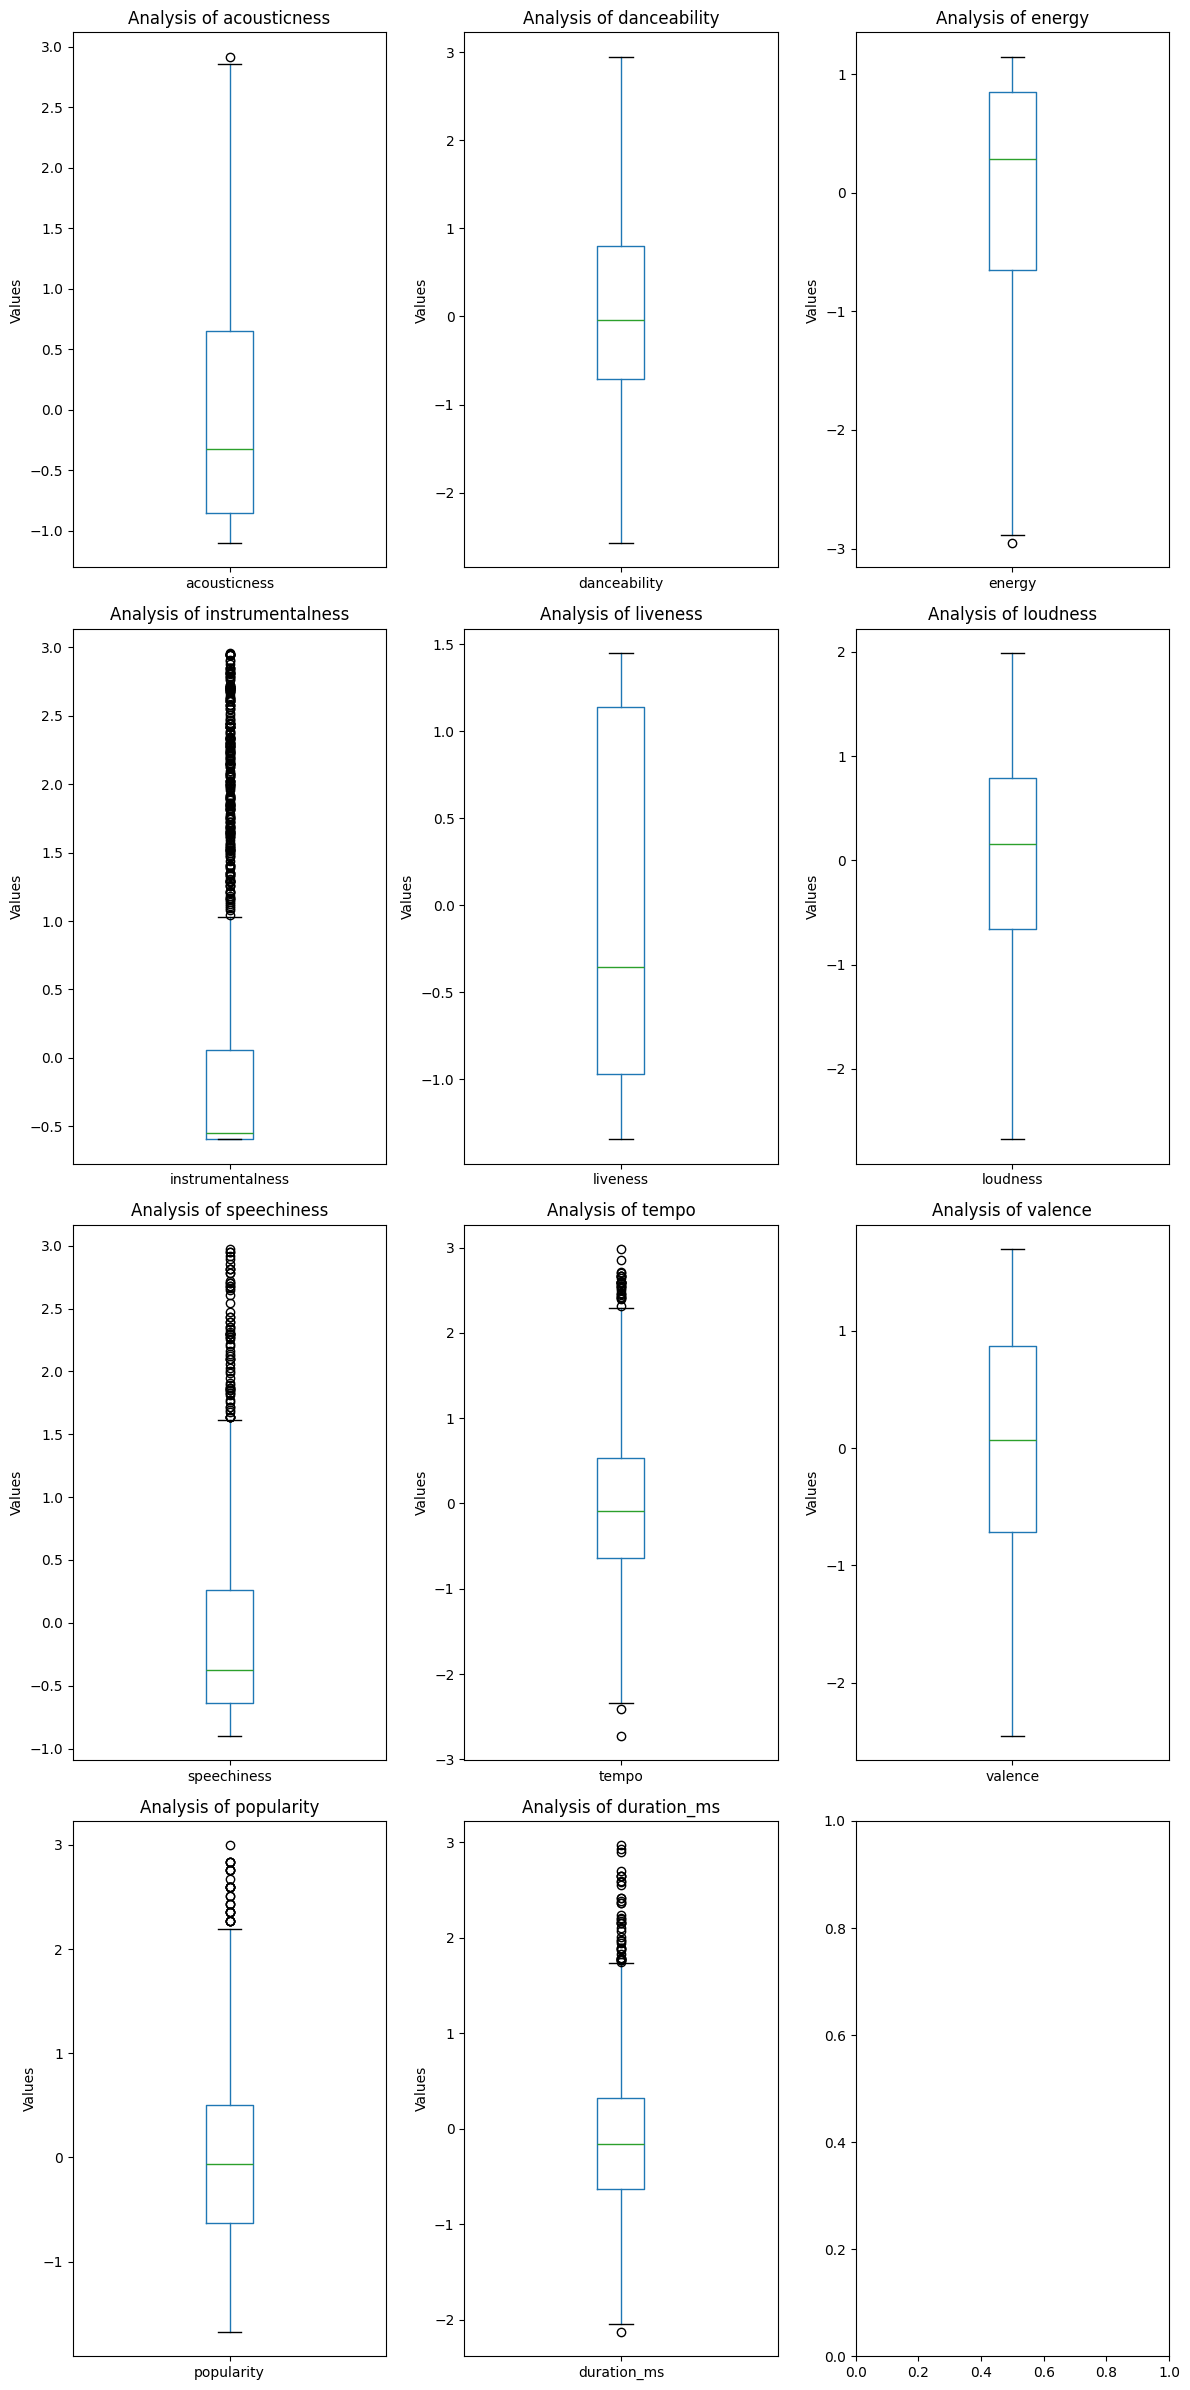

In [269]:

#  create the subplots for each song's properties(numerical only)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 24))

# for more than 1 row - flatten the axes(series type)
axes = axes.flatten()

# plotting a box plot to check the outliers present in each column:
for i, col in enumerate(df[['acousticness',
       'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness',
       'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']]):
    df.boxplot(column=col, ax=axes[i], grid=False)
    axes[i].set_title(f'Analysis of {col}')
    axes[i].set_ylabel('Values')

plt.tight_layout()
plt.show()

#### Conclusion - 
    - After applying standard scaling and outlier detection algorithm z-score, the outlier exists beyond the range [-3, 3], and 102 records are deleted from the data frame.

#### Songs recommendation based on Popularity

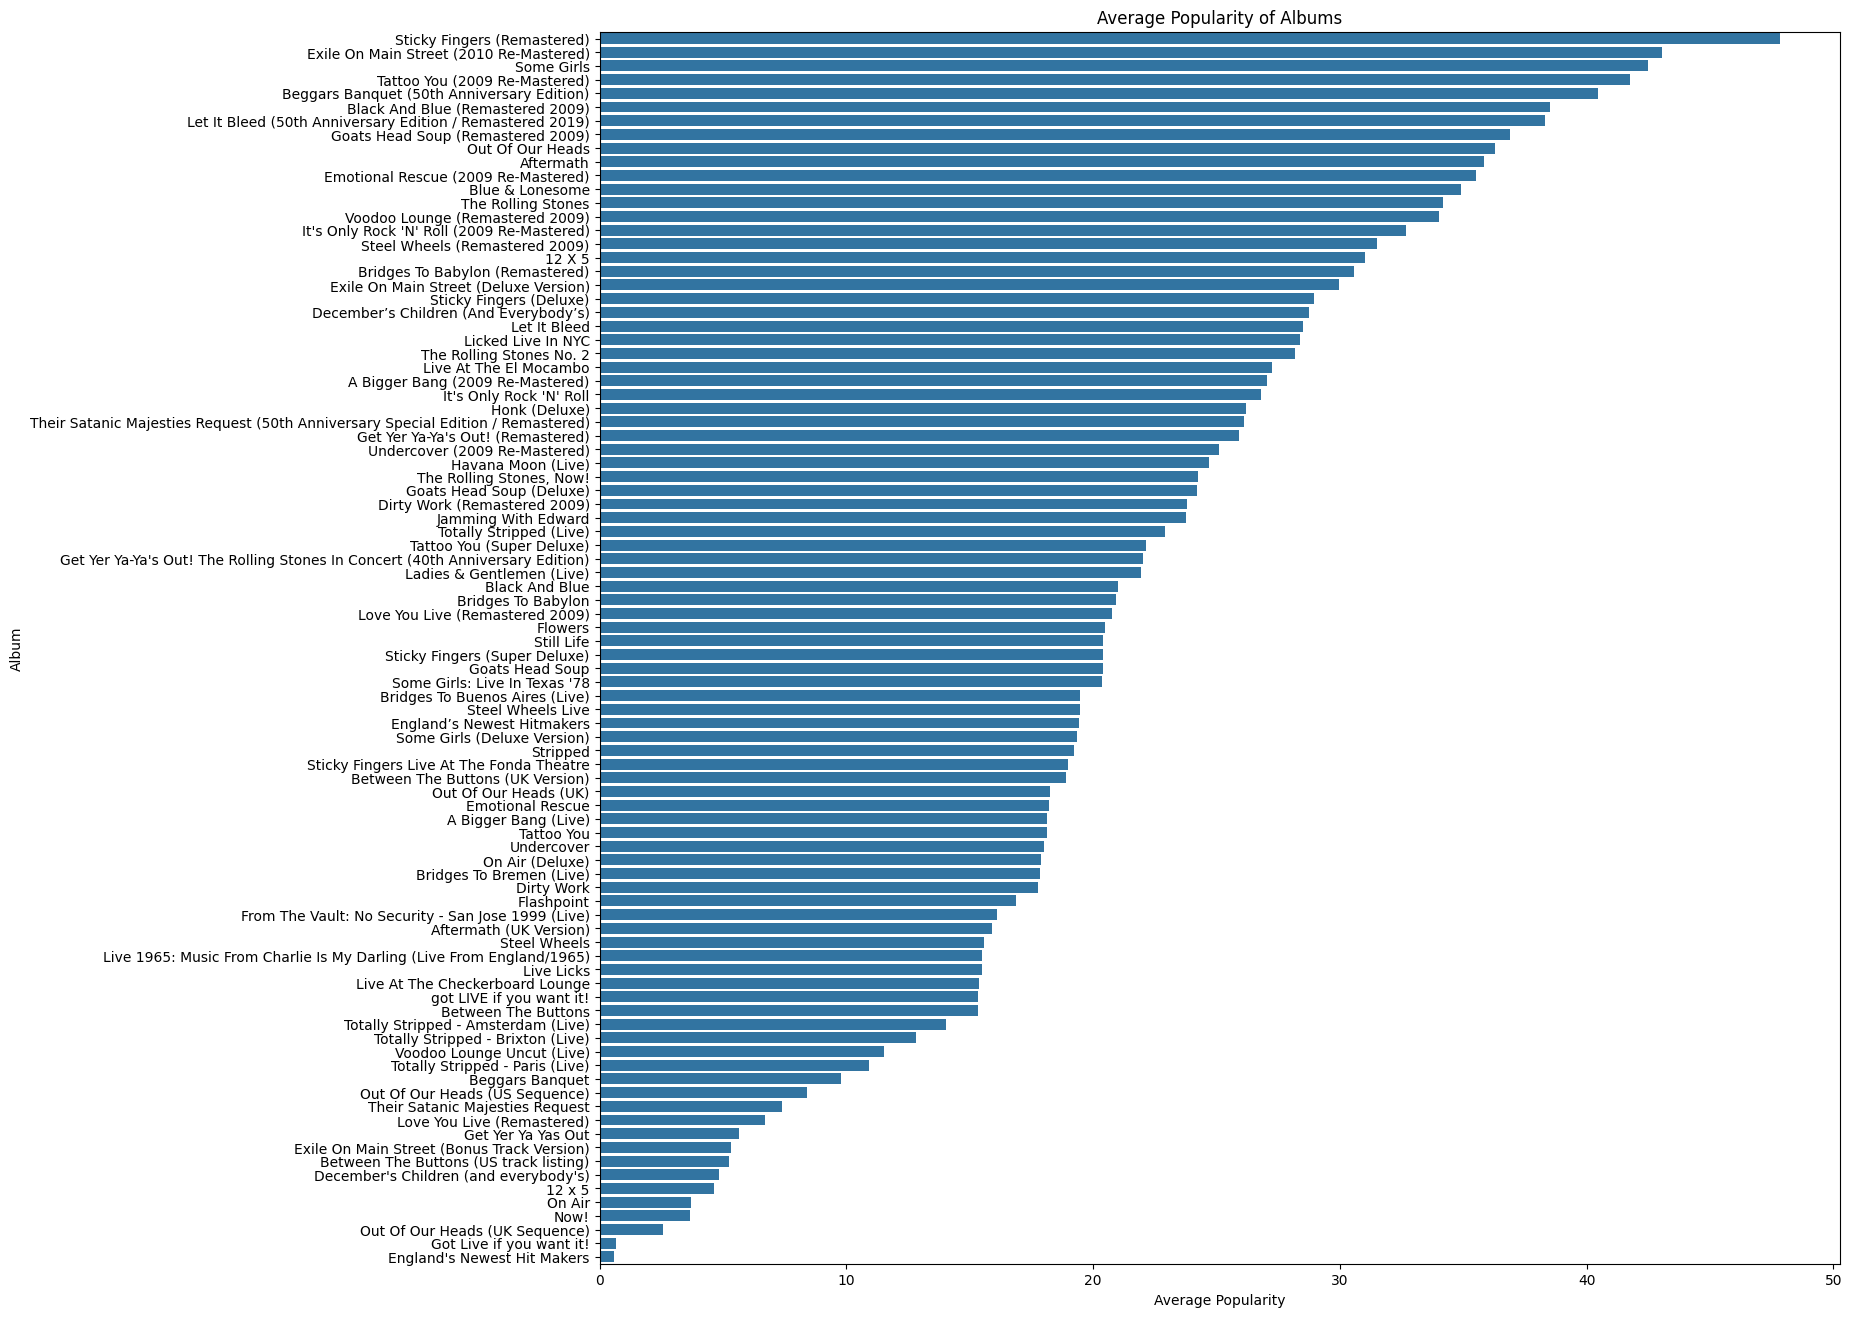

,album,popularity
0,Sticky Fingers (Remastered),47.857143
1,Exile On Main Street (2010 Re-Mastered),43.058824
2,Some Girls,42.500000
3,Tattoo You (2009 Re-Mastered),41.777778
4,Beggars Banquet (50th Anniversary Edition),40.444444


In [341]:
album_popularity = df_original.groupby('album')['popularity'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(16,16))
sns.barplot(y=album_popularity["album"], x=album_popularity["popularity"])
plt.title('Average Popularity of Albums')
plt.xlabel('Average Popularity')
plt.ylabel('Album')
plt.show()

album_popularity.head(5)

#### Two Recommended Songs - 
1. Sticky Fingers (Remastered)
2. Exile On Main Street (2010 Re-Mastered)

#### Encoding Name and album column with Label Encoder 

In [271]:
# name and album column : 
# import LabelEncoder Class from the preprocessing library of the sklearn module
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

# performing labelencoder fit_transform method for name and album column: 
for key in ['name', "album"]: 
    df[key+"_encoded"] = encoder.fit_transform(df[key])

#### Creating new columns from release_date

In [272]:
# create new columns from release_date
df['release_date'] = pd.to_datetime(df['release_date'])

# Extract year from release_date
df['release_year'] = df['release_date'].dt.year

#### Data Visualization

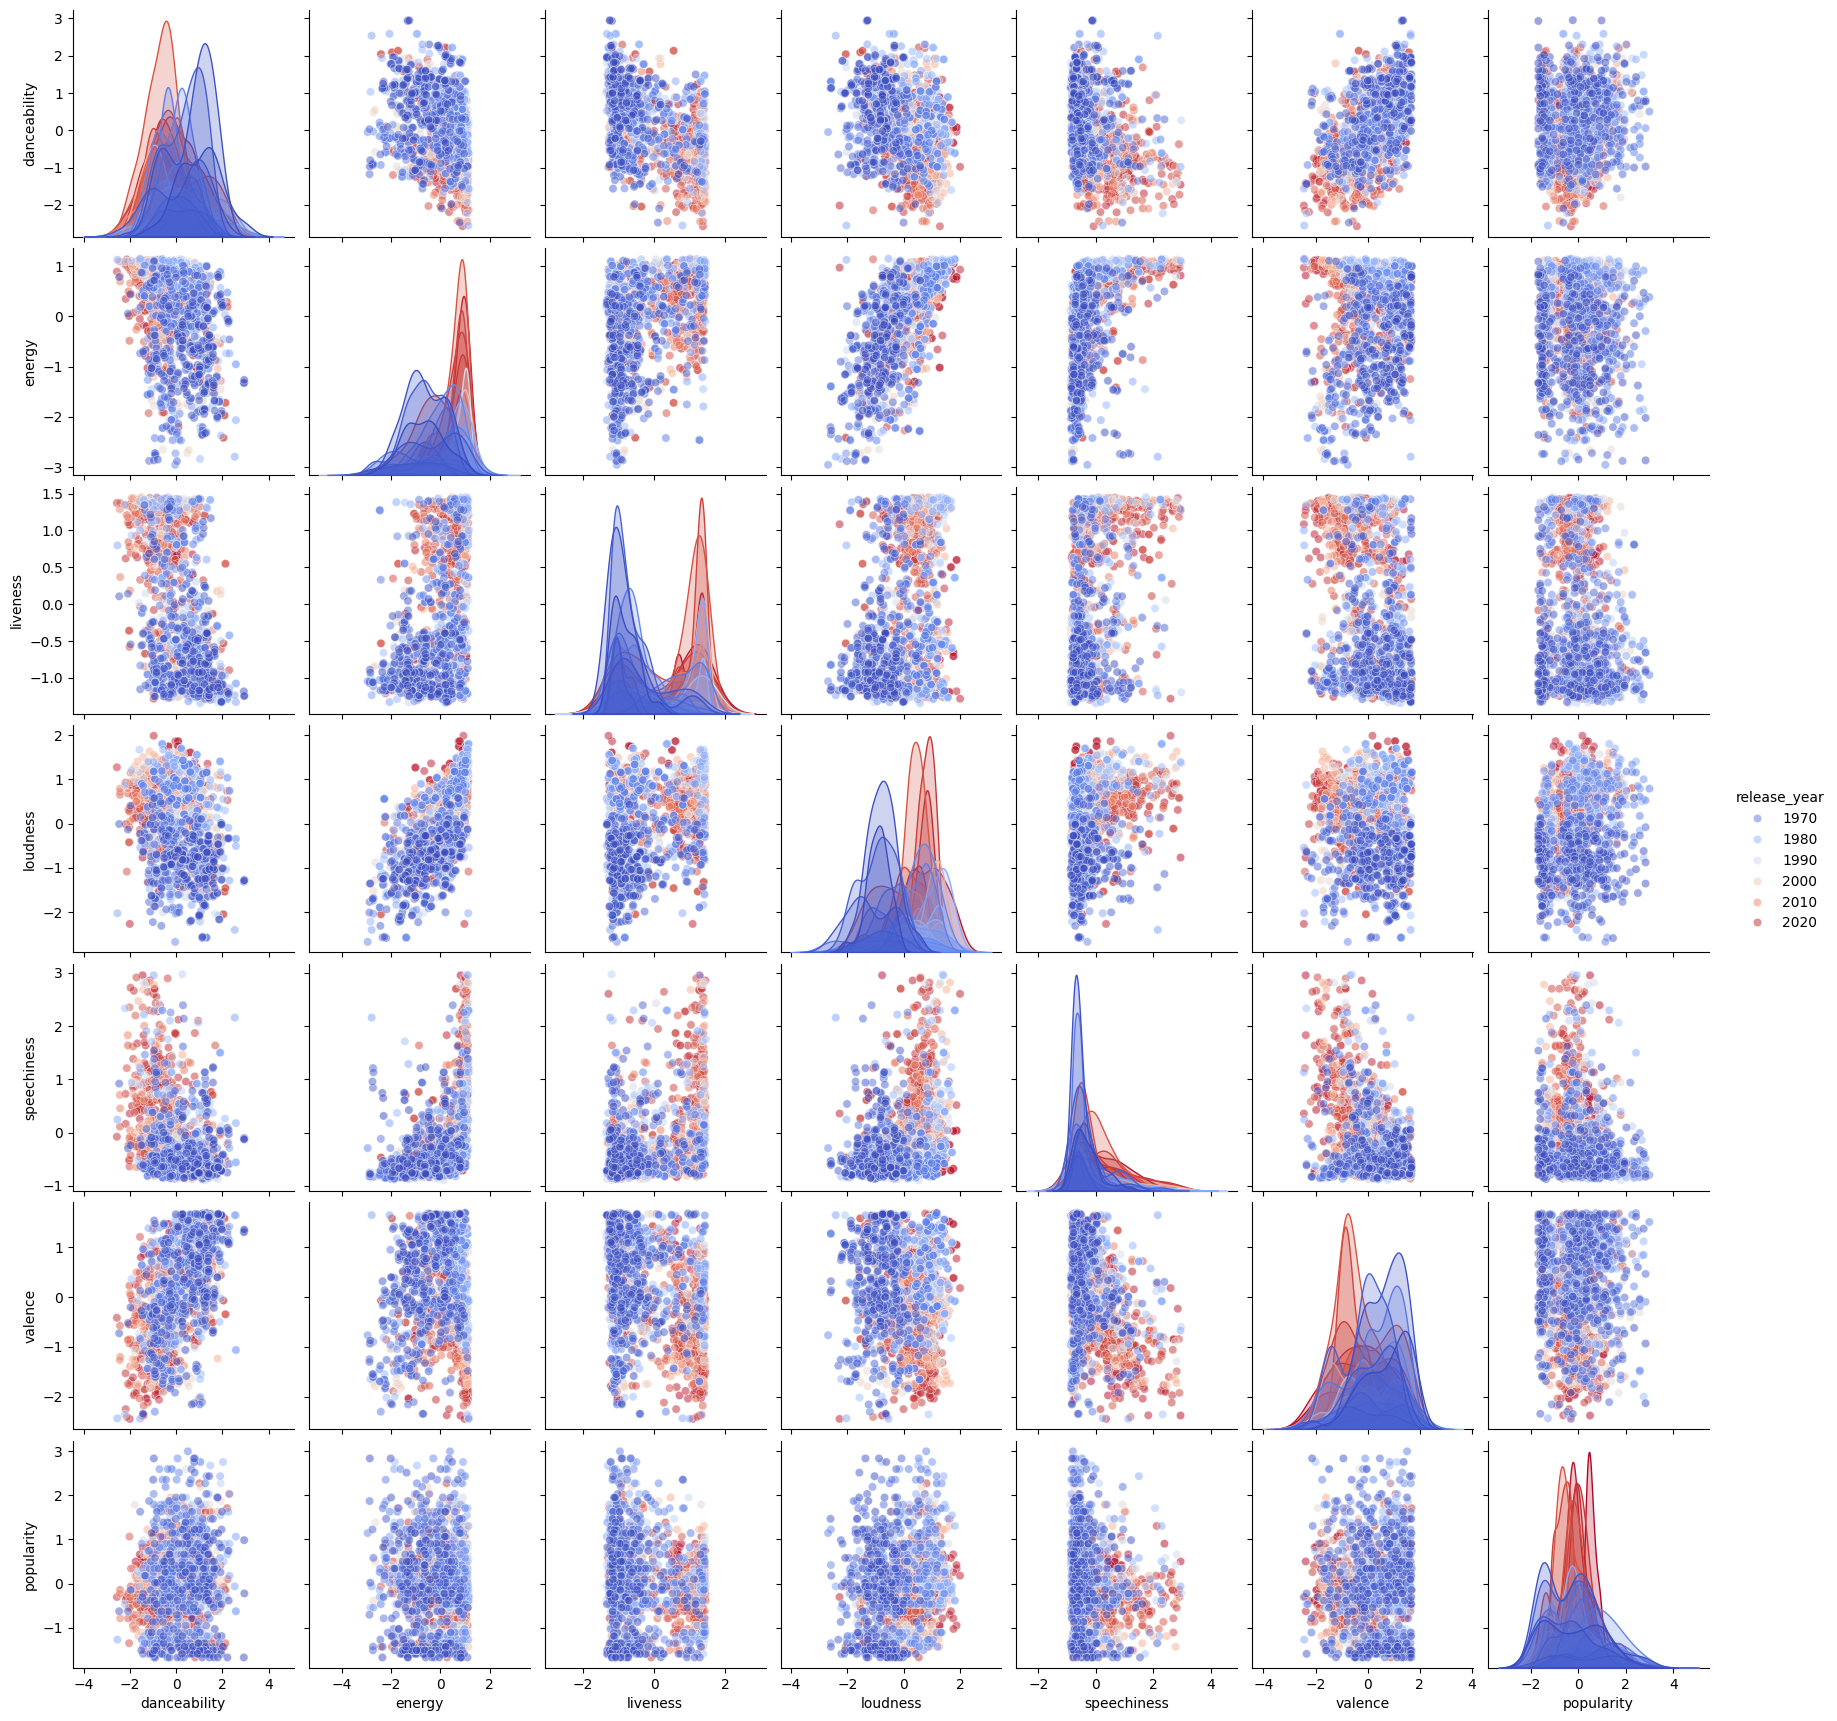

In [273]:
import seaborn as sns

paiplot_cols = [ 'danceability', 'energy', 'liveness', 'loudness', 'speechiness', 'valence', 'popularity', 'release_year']
sns.pairplot(data=df[paiplot_cols], hue='release_year', palette='coolwarm', kind="scatter", plot_kws={'alpha': 0.5})

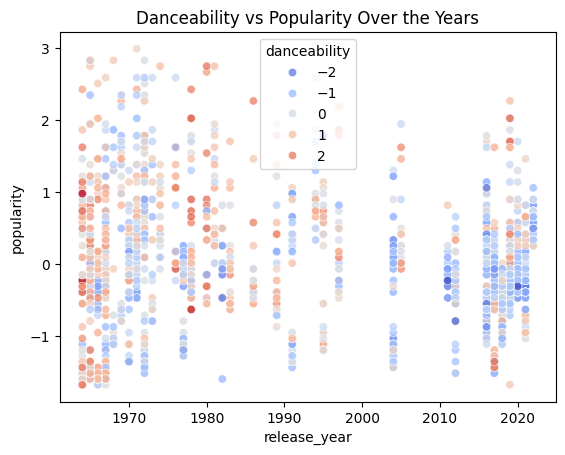

In [276]:
# Using a hue for 'release_year' shows how the trend moves over time
sns.scatterplot(data=df, x='release_year', y='popularity', hue='danceability', palette='coolwarm', alpha=0.75)

plt.title('Danceability vs Popularity Over the Years')
plt.show()

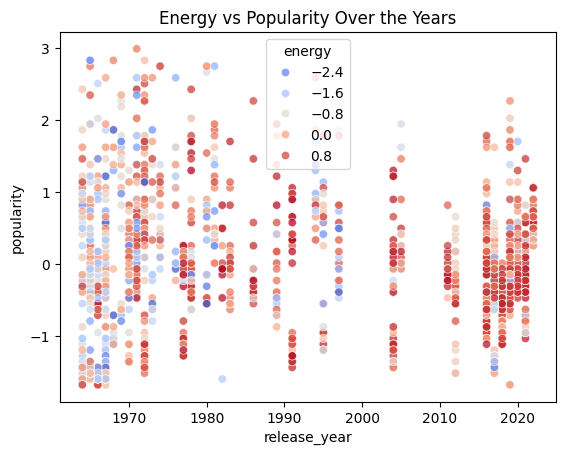

In [275]:
# Using a hue for 'release_year' shows how the trend moves over time
sns.scatterplot(data=df, x='release_year', y='popularity', hue='energy', palette='coolwarm', alpha=0.75)

plt.title('Energy vs Popularity Over the Years')
plt.show()

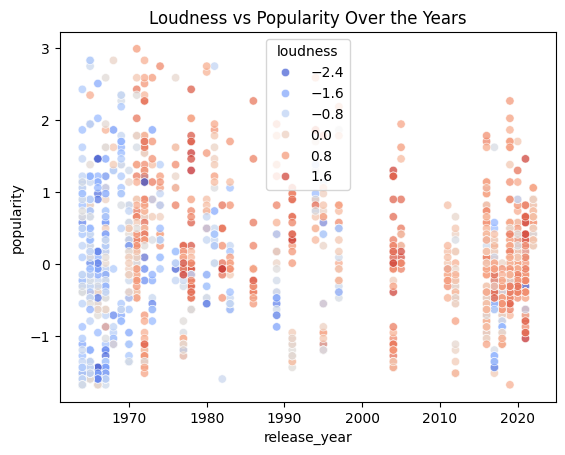

In [277]:
# Using a hue for 'release_year' shows how the trend moves over time
sns.scatterplot(data=df, x='release_year', y='popularity', hue='loudness', palette='coolwarm', alpha=0.75)

plt.title('Loudness vs Popularity Over the Years')
plt.show()

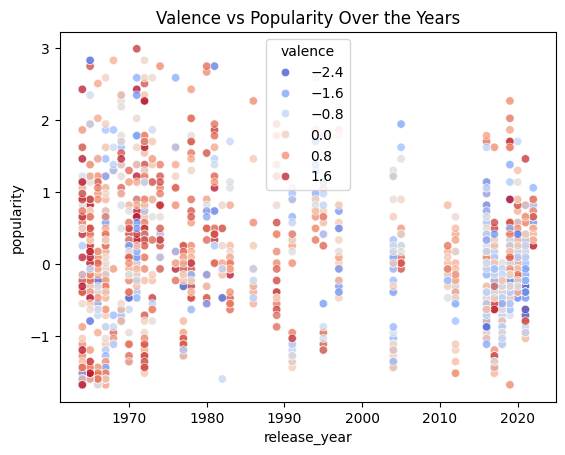

In [278]:
# Using a hue for 'release_year' shows how the trend moves over time
sns.scatterplot(data=df, x='release_year', y='popularity', hue='valence', palette='coolwarm', alpha=0.75)

plt.title('Valence vs Popularity Over the Years')
plt.show()

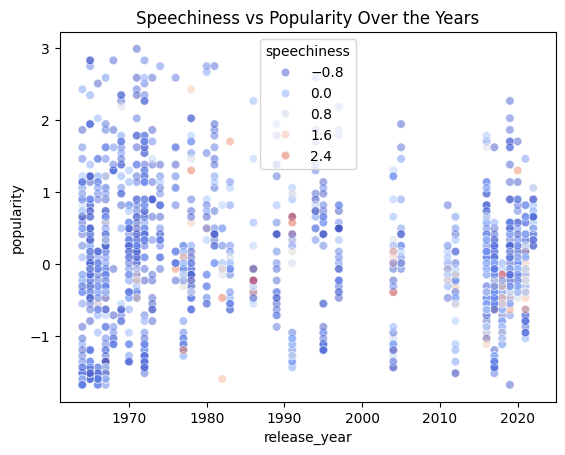

In [295]:
# Using a hue for 'release_year' shows how the trend moves over time
sns.scatterplot(data=df, x='release_year', y='popularity', hue='speechiness', palette='coolwarm', alpha=0.5)

plt.title('Speechiness vs Popularity Over the Years')
plt.show()

<Axes: >

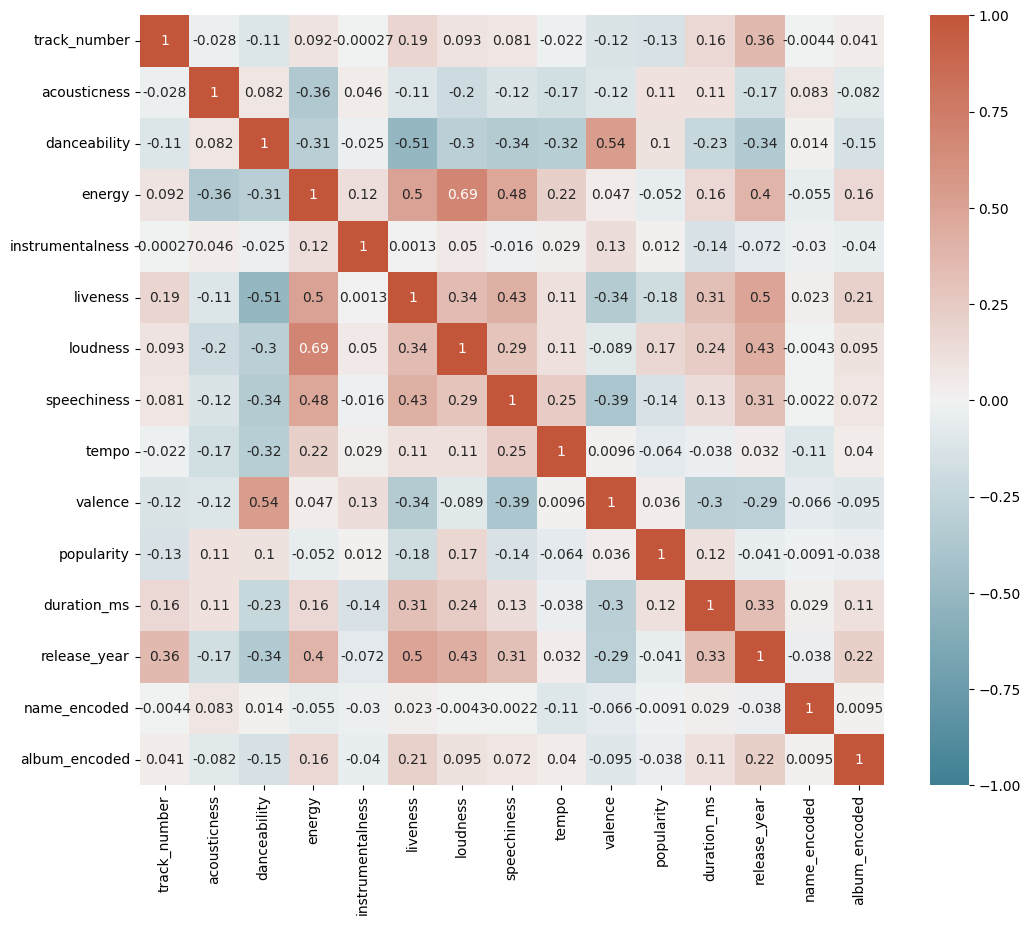

In [280]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap=sns.diverging_palette(220, 20, as_cmap=True))

#### Visual Observations
- energy has a positive correlation with - (liveness, loudness and speechiness)
- release_year has a positive correlation with - (liveness, loudness and speechiness), which shows the music trend towards more energetic songs,
- loudness and energy have the highest positive correlation of 0.7
- valence and danceability have a positive correlation of 0.55
- liveness and danceability have the highest negative correlation of -0.52
- Scatter chart shows popularity in liveness, loudness and speechiness characteristics over the year.

## PCA

In [281]:
# importing PCA Class from decompostion library of scikit-learn module
from sklearn.decomposition import PCA

In [284]:
df.shape

(1508, 18)

In [285]:
df.head(1)
df.columns

Index(['name', 'album', 'release_date', 'track_number', 'acousticness',
       'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness',
       'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms',
       'release_year', 'name_encoded', 'album_encoded'],
      dtype='str')

In [286]:
pca_columns = ['acousticness',
       'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness',
       'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']
train_df = df[pca_columns]
train_df.shape

(1508, 11)

In [324]:
pca=PCA(n_components=11, random_state=42)
pca_11 = pca.fit_transform(train_df)

In [325]:
pca_11

array([[ 1.95244982, -0.851639  ,  1.16047438, ..., -0.90917172,
         0.27390271,  0.5436094 ],
       [ 2.01251295, -0.61206473,  1.27443664, ..., -0.61517838,
         0.18093449,  0.28279338],
       [ 2.57018184, -1.86893212,  0.99394794, ..., -0.42777319,
        -0.48999734,  0.13881903],
       ...,
       [-2.46768115,  0.774035  ,  0.92763798, ..., -0.28296686,
        -0.11388399,  0.15421915],
       [-2.38855949, -0.3897158 , -0.18247434, ..., -0.55639509,
         0.53226357, -0.11073335],
       [-2.06998249,  1.54274031,  0.87759405, ..., -0.44049845,
        -0.34992831,  0.91001646]], shape=(1508, 11))

In [326]:
variance=pca.explained_variance_ratio_

In [327]:
variance.round(decimals=4)*100

array([28.73, 15.54, 11.32, 10.52,  9.19,  6.77,  5.12,  4.49,  4.15,
        2.66,  1.51])

In [328]:
cum_var = variance.cumsum().round(decimals=4)*100
cum_var

array([ 28.73,  44.27,  55.59,  66.11,  75.3 ,  82.06,  87.19,  91.67,
        95.82,  98.49, 100.  ])

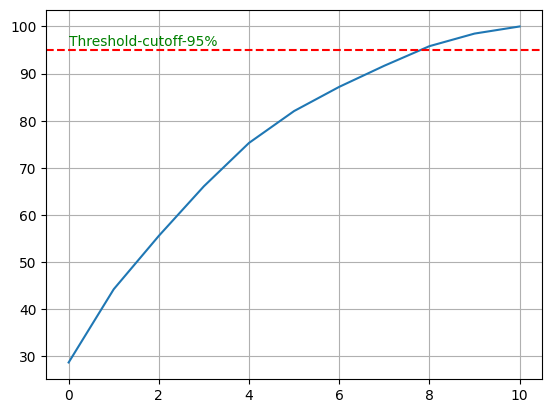

In [329]:
plt.grid()
plt.plot(cum_var)
plt.axhline(color="r",y=95,linestyle="--")
plt.text(0,96,"Threshold-cutoff-95%",color="g")
plt.show()

#### Observations 
- We choose 14 columns for PCA. After performing PCA, we can see cumsum percentage is already above 95% threshold value.
- After reducing columns to 8, we are getting ~95% information above the threshold value.

#### Conclusion
- PCA is a very powerful dimension reduction technique that helps to reduce the size of the data without losing much information. Here, above, we have 14 columns, and we reduced them to 8 columns, and we are getting 95% of the information.

#### Perfoming Cluster Analysis

[11736.093979686459, 10449.861182837712, 9570.585030262382, 9036.719620311567, 8388.416241339153, 7953.7929023038305, 7876.01543239876, 7483.474828253577, 7283.874297540102, 7231.870774200068, 7036.386485171668]


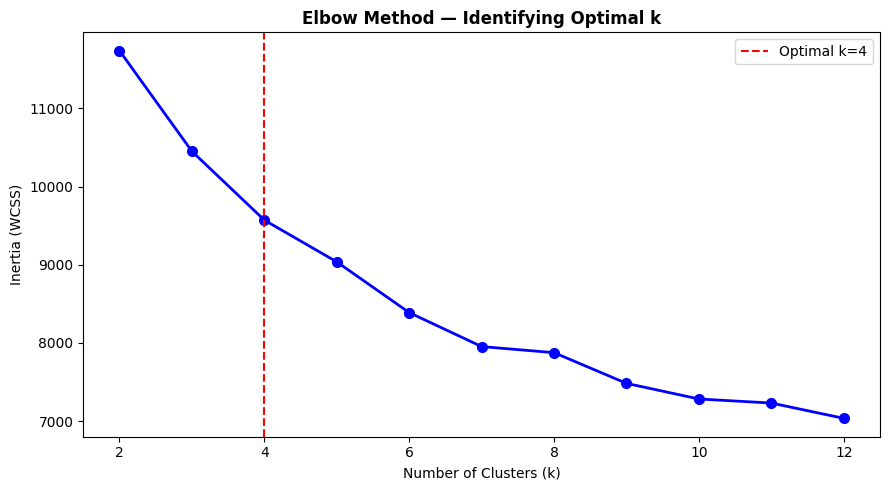

In [349]:
#importing KMeans class from cluster module of the Scikit-learn library
from sklearn.cluster import KMeans

cluster_columns = ['acousticness',
       'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness',
       'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']

inertias = []
k_range = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(df[cluster_columns])
    inertias.append(km.inertia_)
print(inertias)

# Plot
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7)
plt.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Optimal k=4')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Identifying Optimal k', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion
- To classify the data, from the chart, we can consider 4 clusters, which will be fine to perform analysis.
- To classify the data into 4 clusters, we can pick the K-Means clustering algorithm.
- To draw the 11 features into a 2D chart, we need to reduce the dimension to 2 features, so we will be applying PCA techniques on 2 random components.

In [331]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=25,
                max_iter=500, random_state=42)
df['cluster'] = kmeans.fit_predict(df[cluster_columns])

# adding cluster data into the original DataFrame to compare with unmodified values.
df_original['cluster'] = df['cluster']

# print the size of each cluster
df['cluster'].value_counts().sort_index()

cluster
0    365
1    262
2    520
3    361
Name: count, dtype: int64

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


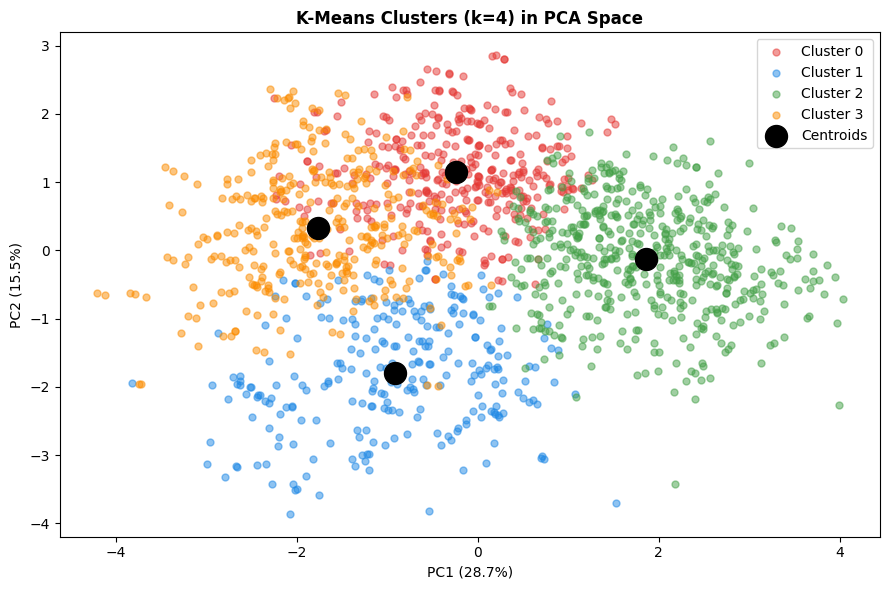

In [332]:
COLOR_CODES = ['#E53935', '#1E88E5', '#43A047', '#FB8C00']
plt.figure(figsize=(9, 6))

for c in range(4):
    mask = df['cluster'] == c
    plt.scatter(pca_11[mask, 0], pca_11[mask, 1], color=COLOR_CODES[c], alpha=0.5, s=25, label=f'Cluster {c}')

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=250, c='black', marker='o', zorder=6, label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('K-Means Clusters (k=4) in PCA Space', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

#### Cluster definition based on features

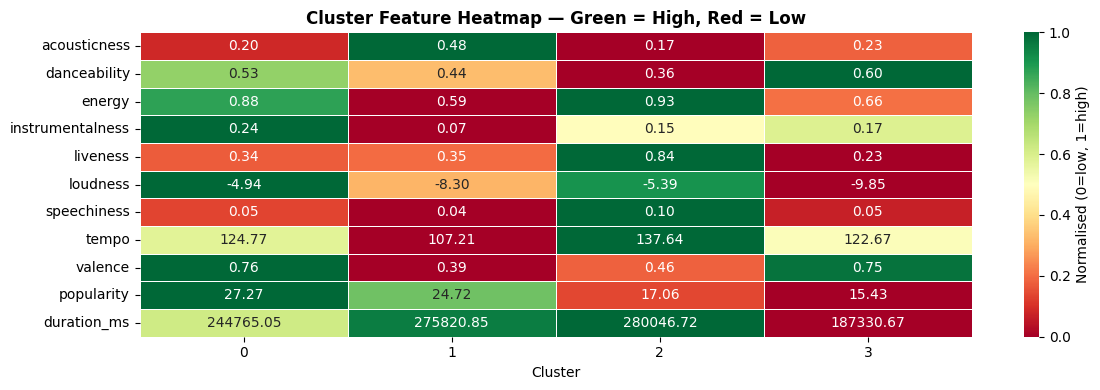

In [335]:
# Getting cluster and corresponding features detiails from the original DataFrame.
cluster_summary = df_original.groupby('cluster')[cluster_columns].mean()

# performing normalisation before ploting into charts
cluster_norm = (cluster_summary - cluster_summary.min()) / (cluster_summary.max() - cluster_summary.min())

plt.figure(figsize=(12, 4))
sns.heatmap(cluster_norm.T, annot=cluster_summary.T, fmt='.2f', cmap='RdYlGn', linewidths=0.5, cbar_kws={'label': 'Normalised (0=low, 1=high)'})
plt.title('Cluster Feature Heatmap — Green = High, Red = Low', fontweight='bold')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

In [347]:
songs = df_original.groupby('cluster')["album"].agg(lambda x: x.mode()[0])
songs

cluster
0                                        Honk (Deluxe)
1    Their Satanic Majesties Request (50th Annivers...
2                           Voodoo Lounge Uncut (Live)
3                               Aftermath (UK Version)
Name: album, dtype: str

#### Cluster 0 (instrumentalness , popularity, loudness )
     - ("Popular High-Energy Studio Hits")
    
#### Cluster 1 (acousticness)
     - ("Mellow Acoustic Chill Studio Tracks")

#### Cluster 2 (tempo, liveness, energy, speechness )
    - (Live High Energy Rock Tracks)

#### Cluster 3 (dancability, valence)
    - (Groovy Upbeat Studio Tracks)